### Hardware Profiling & Latency Baseline

The C++ pipeline was profiled using `cv::TickMeter` to measure the raw inference latency.

* **CPU Fallback Latency:** ~74.1 ms
* **Frames Per Second (FPS):** ~13.5 FPS
* **Fragmentation Resolution:** The Kalman filter successfully bridged a 3-frame occlusion gap for Target ID: 1, maintaining lock without re-assignment.

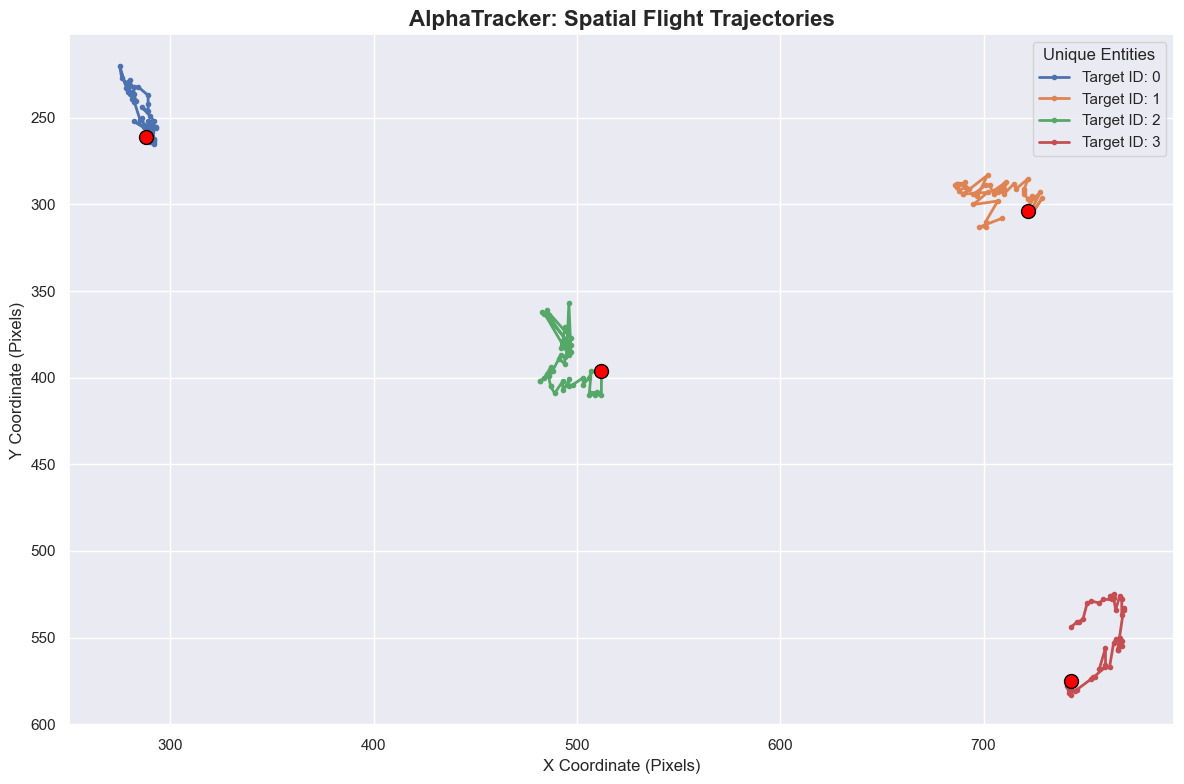

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

df = pd.read_csv("build/flight_telemetry.csv")

track_counts = df['Track_ID'].value_counts()
valid_tracks = track_counts[track_counts > 10].index
filtered_df = df[df['Track_ID'].isin(valid_tracks)]

plt.figure(figsize=(12, 8))

for track_id in valid_tracks:
    track_data = filtered_df[filtered_df['Track_ID'] == track_id]
    
    plt.plot(track_data['X_Center'], track_data['Y_Center'], 
             marker='o', markersize=3, linestyle='-', linewidth=2, 
             label=f'Target ID: {track_id}')
    
    start_point = track_data.iloc[0]
    plt.scatter(start_point['X_Center'], start_point['Y_Center'], 
                color='red', s=100, zorder=5, edgecolors='black')

plt.gca().invert_yaxis()

plt.title('AlphaTracker: Spatial Flight Trajectories', fontsize=16, fontweight='bold')
plt.xlabel('X Coordinate (Pixels)', fontsize=12)
plt.ylabel('Y Coordinate (Pixels)', fontsize=12)
plt.legend(title='Unique Entities')
plt.tight_layout()

plt.show()

# AlphaTracker: Bare-Metal Edge Inference System
**Architecture Overview**
This project implements a real-time Multi-Object Tracking (MOT) engine for agricultural pest detection. 
To bypass the latency constraints of standard Python environments, the inference engine is written entirely in C++ utilizing OpenCV DNN.

**Tracking Physics**
The system resolves track fragmentation and occlusion via a custom SORT implementation.
1. **Kalman Filters:** Predict bounding box coordinate matrices across temporal frames.
2. **Hungarian Algorithm:** Computes the globally optimal Intersection over Union (IoU) assignment matrix, guaranteeing ID persistence even when YOLO detection confidence drops.

The raw coordinate telemetry is serialized to a CSV via the C++ engine and visualized below.